# Case Study 2: House Price Prediction

## Business Problem

A real-estate company wants to predict the selling price of houses
based on features such as area, number of bedrooms, bathrooms,
location, and other property characteristics.

## Problem Type

**Regression**

The target variable (house price) is a continuous numerical value.

## Business Objective

Build a machine learning model that can accurately predict house prices
and help the company make better pricing and investment decisions.

## Success Metrics

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score (R-squared)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing(as_frame=True)

# Convert to DataFrame
df = housing.frame

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 9)


In [3]:
print("Columns:")
print(df.columns.tolist())

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [6]:
# Check target variable
print("Target Variable: MedHouseVal")
print("Minimum Price:", df["MedHouseVal"].min())
print("Maximum Price:", df["MedHouseVal"].max())
print("Average Price:", df["MedHouseVal"].mean())

Target Variable: MedHouseVal
Minimum Price: 0.14999
Maximum Price: 5.00001
Average Price: 2.0685581690891475


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


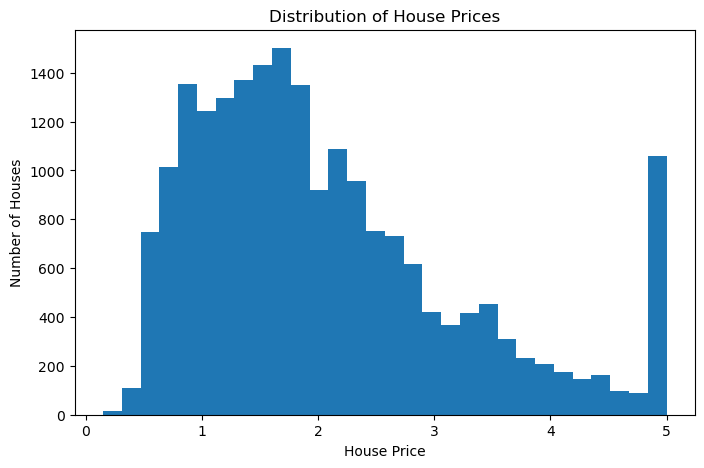

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseVal"], bins=30)

plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")

plt.show()

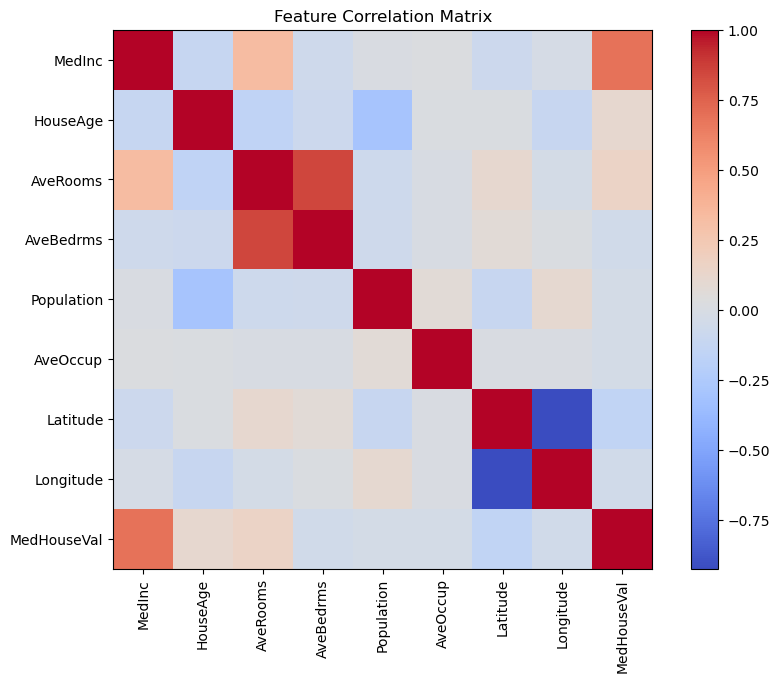

In [9]:
plt.figure(figsize=(10, 7))

plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Feature Correlation Matrix")

plt.show()

In [10]:
# Separate features and target

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [11]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


In [13]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

In [14]:
# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [15]:
# Predict house prices
y_pred = model.predict(X_test)

print("First 10 Actual Prices:")
print(y_test.head(10).values)

print("\nFirst 10 Predicted Prices:")
print(y_pred[:10])

First 10 Actual Prices:
[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]

First 10 Predicted Prices:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [16]:
# Display feature coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
MAE  : 0.5332001304956558
RMSE : 0.7455813830127762
R² Score: 0.575787706032451


In [18]:
print("R² Score (%):", r2 * 100)

R² Score (%): 57.5787706032451


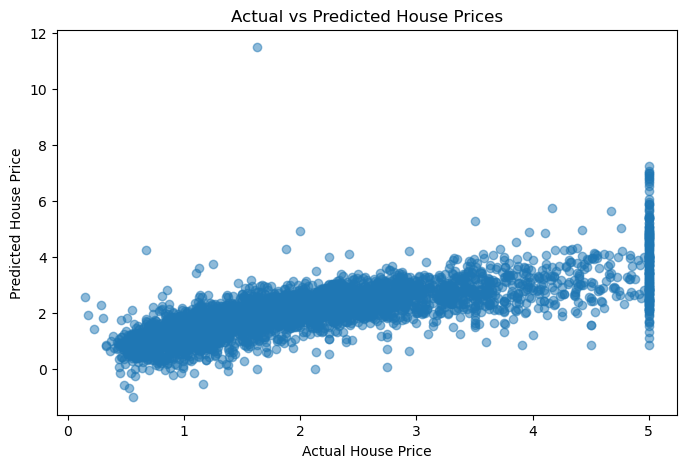

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

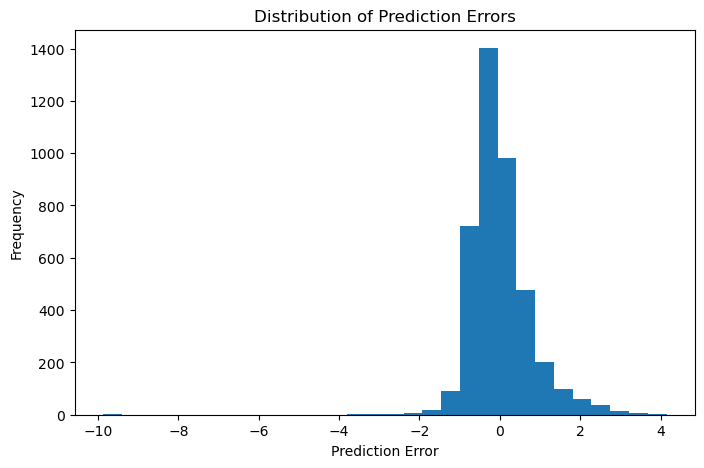

In [20]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

## Model Evaluation & Business Interpretation

The Linear Regression model was evaluated using three important metrics:

- **MAE (Mean Absolute Error):** Measures the average difference between
  actual and predicted house prices.
- **RMSE (Root Mean Squared Error):** Measures prediction error and gives
  more importance to larger errors.
- **R² Score:** Shows how much variation in house prices is explained by
  the model.

### Business Success Criteria

The model will be considered useful if it:

1. Produces a low MAE.
2. Produces a low RMSE.
3. Achieves a high R² score.
4. Provides reasonably accurate house price predictions for business
   decision-making.

### Business Value

The model can help real-estate businesses:

- Estimate house prices quickly.
- Support property pricing decisions.
- Identify potentially underpriced or overpriced properties.
- Reduce manual effort in price estimation.

## Conclusion

This case study used a Regression approach to predict house prices.
A Linear Regression model was trained using housing features and
evaluated using MAE, RMSE, and R² Score.

The model demonstrates how Machine Learning can be used to support
real-estate price estimation and business decision-making.

Further improvements could include testing advanced regression models
such as Random Forest, Gradient Boosting, or XGBoost to potentially
improve prediction accuracy.